# imports

In [25]:
from cat_state import *
from state_prep_variational import *
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import json
import os

# example target state

In [11]:
alpha = 1.5
N = 9 # truncate to N Fock levels
cat_odd = cat_state(alpha, N, "odd")
cat_even = cat_state(alpha, N, "even")

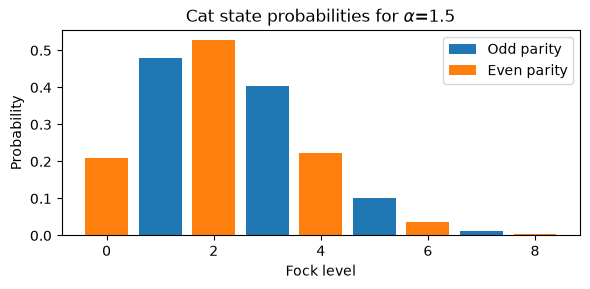

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
colors = ['tab:blue', 'tab:orange']

for i, cat in enumerate([cat_odd, cat_even]):
    probabilities = np.abs(cat)**2
    ax.bar(range(N), probabilities, color=colors[i], label=f"{'Odd' if i == 0 else 'Even'} parity")
    ax.set_title(rf"Cat state probabilities for $\alpha$={alpha}")
    ax.set_xlabel("Fock level")
    ax.set_ylabel("Probability")
    ax.legend()
plt.tight_layout()

# ansatz circuit

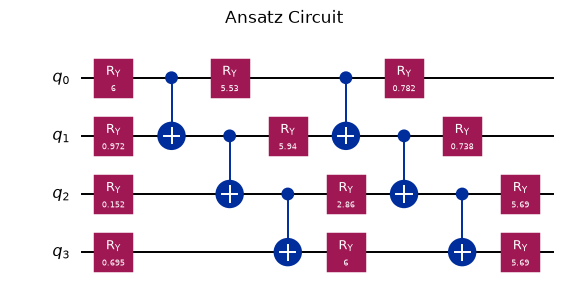

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
N_qubits = num_qubits(N)
ansatz = make_ansatz(num_qubits=N_qubits, reps=2)
theta = np.random.uniform(0, 2*np.pi, ansatz.num_parameters) # random initial angles
circuit = ansatz.assign_parameters(theta)
circuit.draw(output='mpl', ax=ax)
ax.set_title("Ansatz Circuit")
plt.tight_layout()

In [14]:
# embed cat states in qubit hilbert space
cat_odd_embedded = embed_state(cat_odd, N_qubits)
cat_even_embedded = embed_state(cat_even, N_qubits)

# optimization

In [15]:
optimized_circuit_even, optimized_state_even, history_even = optimize_circuit(ansatz, theta, target_state=cat_even_embedded, maxiter=100)
print("Optimizing for even cat state:")
print(f"{len(history_even)} iterations")
print(f"Initial fidelity: {history_even[0]}")
print(f"Final fidelity: {history_even[-1]}")

Optimizing for even cat state:
64 iterations
Initial fidelity: 0.7137922321376614
Final fidelity: 0.9872167291649409


In [16]:
optimized_circuit_odd, optimized_state_odd, history_odd = optimize_circuit(ansatz, theta, target_state=cat_odd_embedded, maxiter=100)
print("Optimizing for odd cat state:")
print(f"{len(history_odd)} iterations")
print(f"Initial fidelity: {history_odd[0]}")
print(f"Final fidelity: {history_odd[-1]}")

Optimizing for odd cat state:
59 iterations
Initial fidelity: 0.4548629288691042
Final fidelity: 0.9969305920476567


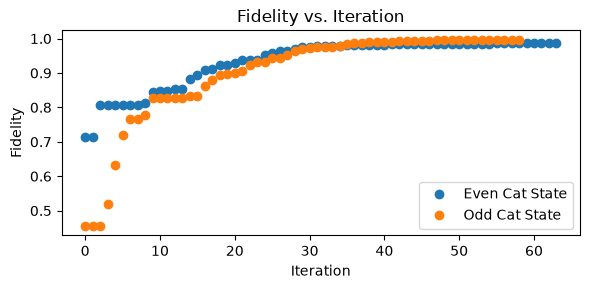

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(np.array(history_even), marker='o', linestyle='', color='tab:blue', label='Even Cat State')
ax.plot(np.array(history_odd), marker='o', linestyle='', color='tab:orange', label='Odd Cat State')

ax.set_title("Fidelity vs. Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Fidelity")
ax.legend()
plt.tight_layout()

# fidelity vs truncation level and circuit depth

In [104]:
alpha = 1.5
Ns = np.arange(5, 21, 1)
parity = 'odd'
N_trials = 100
maxiter = 500
N_reps = [7,8,9]

final_fidelities = []
for N in tqdm(Ns, desc='Truncation N'):
    cat = cat_state(alpha, N, parity)
    N_qubits = num_qubits(N)
    cat_embedded = embed_state(cat, N_qubits)

    final_fidelities_rep = []
    for reps in N_reps:
        ansatz = make_ansatz(num_qubits=N_qubits, reps=reps)
        def run_trial(trial):
            theta = np.random.uniform(0, 2*np.pi, ansatz.num_parameters)
            _, _, history = optimize_circuit(ansatz, theta, target_state=cat_embedded, maxiter=maxiter)
            return history[-1]
        final_fidelities_trial = Parallel(n_jobs=16)(
            delayed(run_trial)(trial) for trial in range(N_trials)
        )
        final_fidelities_rep.append(final_fidelities_trial)
    final_fidelities.append(final_fidelities_rep)

final_fidelities = np.array(final_fidelities)

Truncation N: 100%|██████████| 16/16 [07:18<00:00, 27.42s/it]


In [105]:
final_fidelities_means = np.mean(final_fidelities, axis=2).T
final_fidelities_stds = np.std(final_fidelities, axis=2).T

In [106]:
filename = "cat_state_optimization_results"
filenum = len([f for f in os.listdir("data") if f.startswith(filename)]) + 1
data_path = os.path.join(os.getcwd(), "data", f"{filename}_{filenum}.json")
results = {
    "Ns": Ns.tolist(),
    "alpha": alpha,
    "maxiter": maxiter,
    "N_trials": N_trials,
    "parity": parity,
    "N_reps": N_reps,
    "final_fidelities_means": final_fidelities_means.tolist(),
    "final_fidelities_stds": final_fidelities_stds.tolist(),
    "final_fidelities": final_fidelities.tolist()
}
with open(data_path, "w") as f:
    json.dump(results, f, indent=4)

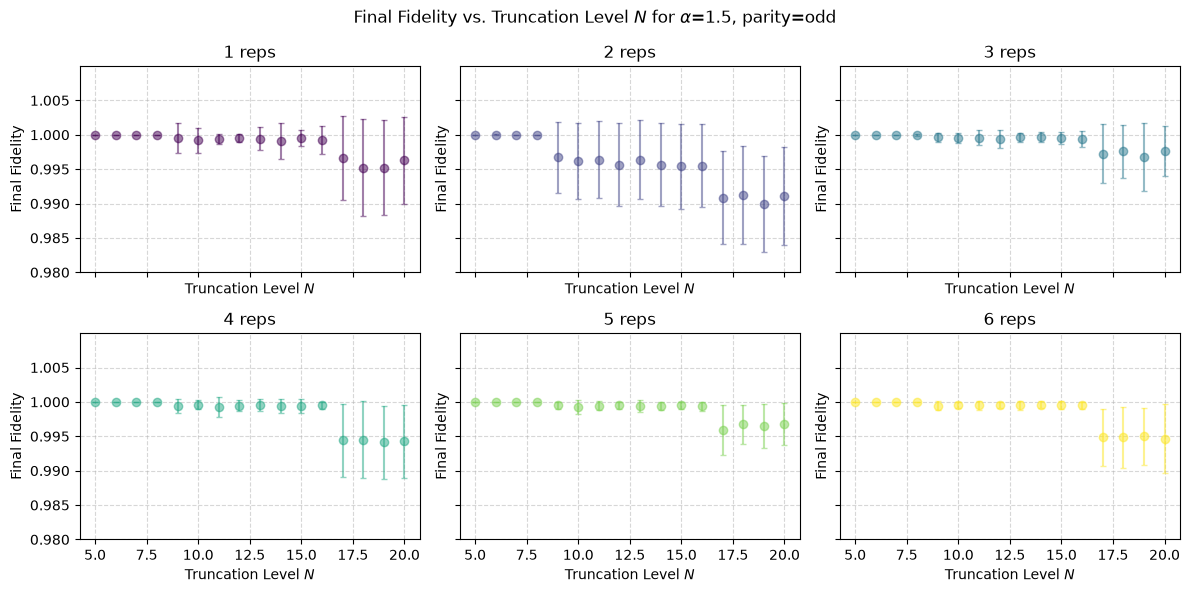

In [103]:
filenum = 7
filename = "cat_state_optimization_results"
data_path = os.path.join(os.getcwd(), "data", f"{filename}_{filenum}.json")
with open(data_path, "r") as f:
    data = json.load(f)
Ns = np.array(data["Ns"])
alpha = data["alpha"]
maxiter = data["maxiter"]
N_trials = data["N_trials"]
parity = data["parity"]
N_reps = data["N_reps"]
final_fidelities_means = np.array(data["final_fidelities_means"])
final_fidelities_stds = np.array(data["final_fidelities_stds"])
final_fidelities = np.array(data["final_fidelities"])

n_cols = int(np.ceil(np.sqrt(len(N_reps))))
n_rows = int(np.ceil(len(N_reps) / n_cols))
figsize = (4 * n_cols, 3 * n_rows)
fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True, sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(N_reps)))
for i, reps in enumerate(N_reps):
    ax = axs.flat[i] if len(N_reps) > 1 else axs
    ax.errorbar(Ns, final_fidelities_means[:][i], yerr=final_fidelities_stds[i], marker='o', linestyle='', capsize=2, color=colors[i], alpha=0.5)
    ax.set_title(f"{reps} reps")
    ax.set_xlabel("Truncation Level $N$")
    ax.set_ylabel("Final Fidelity")
    ax.set_ylim(final_fidelities_means.min() - 0.01, final_fidelities_means.max() + 0.01)
    ax.grid(True, linestyle='--', alpha=0.5)
fig.suptitle(rf"Final Fidelity vs. Truncation Level $N$ for $\alpha$={alpha}, parity={parity}")
plt.tight_layout()

In [166]:
filenums = [7, 8]
final_fidelities_means_all = []
final_fidelities_stds_all = []
N_reps_all = []
for filenum in filenums:
    filename = "cat_state_optimization_results"
    data_path = os.path.join(os.getcwd(), "data", f"{filename}_{filenum}.json")
    with open(data_path, "r") as f:
        data = json.load(f)
    Ns = np.array(data["Ns"])
    alpha = data["alpha"]
    maxiter = data["maxiter"]
    N_trials = data["N_trials"]
    parity = data["parity"]
    N_reps = data["N_reps"]
    N_reps_all.append(N_reps)
    final_fidelities_means = np.array(data["final_fidelities_means"])
    final_fidelities_stds = np.array(data["final_fidelities_stds"])
    final_fidelities = np.array(data["final_fidelities"])
    final_fidelities_means_all.append(np.vsplit(final_fidelities_means, len(N_reps)))
    final_fidelities_stds_all.append(np.vsplit(final_fidelities_stds, len(N_reps)))
final_fidelities_means_all = np.vstack(final_fidelities_means_all).squeeze()
final_fidelities_stds_all = np.vstack(final_fidelities_stds_all).squeeze()
N_reps_all = np.array([item for sublist in N_reps_all for item in sublist])

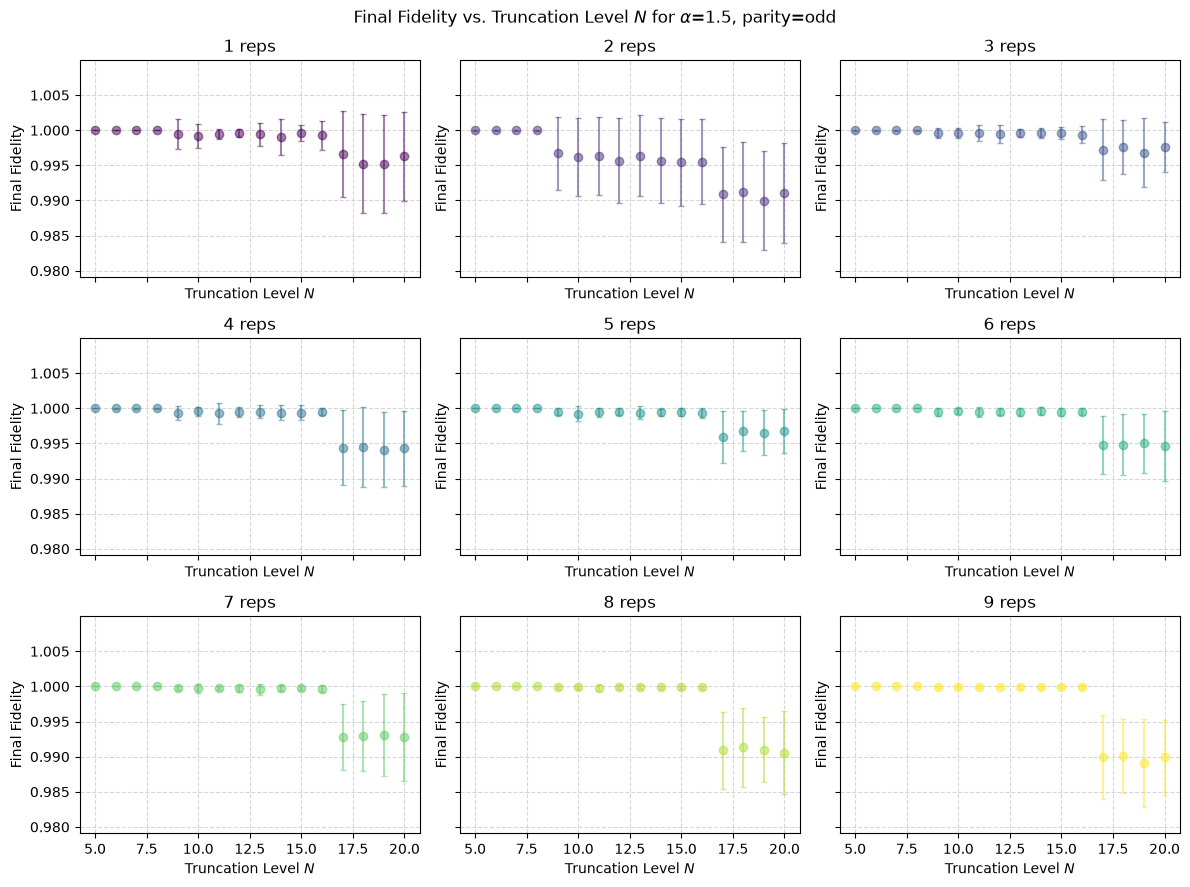

In [181]:
n_cols = int(np.ceil(np.sqrt(len(N_reps_all))))
n_rows = int(np.ceil(len(N_reps_all) / n_cols))
figsize = (4 * n_cols, 3 * n_rows)
fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True, sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(N_reps_all)))
for i, reps in enumerate(N_reps_all):
    ax = axs.flat[i] if len(N_reps_all) > 1 else axs
    ax.errorbar(Ns, final_fidelities_means_all[i], yerr=final_fidelities_stds_all[i], marker='o', linestyle='', capsize=2, color=colors[i], alpha=0.5)
    ax.set_title(f"{reps} reps")
    ax.set_xlabel("Truncation Level $N$")
    ax.set_ylabel("Final Fidelity")
    ax.set_ylim(final_fidelities_means_all.min() - 0.01, final_fidelities_means_all.max() + 0.01)
    ax.grid(True, linestyle='--', alpha=0.5)
fig.suptitle(rf"Final Fidelity vs. Truncation Level $N$ for $\alpha$={alpha}, parity={parity}")
plt.tight_layout()